In [48]:
#Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#Loaded the Phising email Dataset:


import pandas as pd

data = pd.read_csv("/content/spam.csv")

print("Dataset shape:", data.shape)
data.head()

#show that there are 2 columns and 5752 enteries.

Dataset shape: (5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
#Number of enteries (SPAM / HAM)
print(data['Category'].value_counts())

#checking the distribution of data

Category
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
print("Sample Emails:\n")
print(data['Message'].head(5))

Sample Emails:

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: object


In [5]:
print("Missing Values:\n")
print(data.isnull().sum())


#shows no missiing value.

Missing Values:

Category    0
Message     0
dtype: int64


In [8]:
#if there were missing values so:

#Adding them on my own to show techniques and clean data.
import numpy as np
data.loc[5, 'Message'] = np.nan
data.loc[10, 'Message'] = np.nan

print("Dataset with simulated missing values:")
print(data.iloc[3:12])
print("\n")

#Now detect them:

print("Missing Values in Dataset:\n")
print(data.isnull().sum())
print("\n")


#drop thos values:

data = data.dropna(subset=['Message'])

print("Dataset shape after removing missing values:", data.shape)
print("\n")


#show cleaned data(No missing values):

print("Missing Values After Cleaning:\n")
print(data.isnull().sum())




Dataset with simulated missing values:
   Category                                            Message
3       ham  U dun say so early hor... U c already then say...
4       ham  Nah I don't think he goes to usf, he lives aro...
5      spam                                                NaN
6       ham  Even my brother is not like to speak with me. ...
7       ham  As per your request 'Melle Melle (Oru Minnamin...
8      spam  WINNER!! As a valued network customer you have...
9      spam  Had your mobile 11 months or more? U R entitle...
10      ham                                                NaN
11     spam  SIX chances to win CASH! From 100 to 20,000 po...


Missing Values in Dataset:

Category    0
Message     2
dtype: int64


Dataset shape after removing missing values: (5570, 2)


Missing Values After Cleaning:

Category    0
Message     0
dtype: int64


In [9]:
#TEXT PREPROCESSING:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')


#stopwords = remove the common (repeated) words like is, are etc
#wordnet = convert the text into first form.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [14]:
#Text Cleaning

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

#makes the text lowercase (lower functn)
#makes the text with punctution (sub functn)
#removes the stopwords = this is a message to only message
#Lemmatization = running to run

In [15]:
#Show cleaned data:
data['clean_text'] = data['Message'].apply(clean_text)

data[['Message','clean_text']].head()

,Message,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [50]:
#Extract URL Features and Sentiment Signals:

In [33]:
# Did Feature Engineering as it extracts the cybersecurity related signals from emails like URL or Url length type text etc.
# These features help detect phishing patterns beyond normal text classification

import re
from urllib.parse import urlparse

def extract_features(text):

    urls = re.findall(r'(https?://\S+)', text)

    # Number of URLs in email
    url_count = len(urls)

    # Check if any URL contains IP address instead of domain
    has_ip_url = any(re.search(r'\d+\.\d+\.\d+\.\d+', url) for url in urls)

    # Average URL length
    url_len_avg = sum(len(url) for url in urls)/len(urls) if urls else 0

    # Suspicious domains
    suspicious_domains = ['.xyz', '.tk', '.ml', '.ga']
    suspicious_tld = any(any(domain in url for domain in suspicious_domains) for url in urls)

    # Keyword-based scoring
    urgency_words = ['urgent','immediately','now','limited','expires']
    threat_words = ['suspended','terminated','blocked','legal action']
    reward_words = ['won','free','prize','gift','congratulations']

    text_lower = text.lower()

    urgency_score = sum(word in text_lower for word in urgency_words)
    threat_score = sum(word in text_lower for word in threat_words)
    reward_score = sum(word in text_lower for word in reward_words)

    return pd.Series({
    'url_count': url_count,
    'has_ip_url': has_ip_url,
    'url_len_avg': url_len_avg,
    'suspicious_tld': suspicious_tld,
    'urgency_score': urgency_score,
    'threat_score': threat_score,
    'reward_score': reward_score
})

# Applying feature extraction
data[['url_count','has_ip_url','url_len_avg','suspicious_tld',
      'urgency_score','threat_score','reward_score']] = data['Message'].apply(extract_features)


#extracted all the phising signals and  converted them in structured format with scores.

In [49]:
#Combine TF-IDF Classifier with Rule-Based Checks

In [34]:
# Using advanced TF-IDF with more features and bigrams
# Helps capture phrases like "verify account", "click now" which are used for phishing.

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2)  #both word and key pair words (1,2)
)

X_text = vectorizer.fit_transform(data['clean_text'])

# Display shape of TF-IDF matrix
print("Feature Matrix Shape:", X_text.shape)

# Vocabulary size
print("Vocabulary Size:", len(vectorizer.get_feature_names_out()))


Feature Matrix Shape: (5570, 30000)
Vocabulary Size: 30000


In [35]:
# Combining TF-IDF features with engineered numerical features
# This creates a hybrid feature set (text + cybersecurity signals)

from scipy.sparse import hstack

# Converting all engineered features to numeric (float)
# Required because hstack only supports numeric data types

X_features = data[['url_count','has_ip_url','url_len_avg',
                   'suspicious_tld','urgency_score',
                   'threat_score','reward_score']].astype(float)

X = hstack([X_text, X_features])

#select all cybersecturity related features by combing them as done above
#and converted to numeric by hstack.

In [37]:
#spliting data for training and testing

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:",X_train.shape)
print("Testing samples:",X_test.shape)

#20% for test and 80% for training data.

Training samples: (4456, 30007)
Testing samples: (1114, 30007)


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest handles mixed features better and improves accuracy
model = RandomForestClassifier(n_estimators=300, class_weight='balanced')

model.fit(X_train, y_train)


#imported the randomdforestclassifier as each tree will calculate the result and give the best
#answer (what majority gives)

RandomForestClassifier(class_weight='balanced', n_estimators=300)

In [39]:
# Rule-based phishing detection system
# Each rule represents a common phishing pattern

def rule_engine(row):

    rules_triggered = 0
    total_rules = 6

    if row['has_ip_url']:
        rules_triggered += 1

    if row['url_count'] > 2:
        rules_triggered += 1

    if row['suspicious_tld']:
        rules_triggered += 1

    if row['urgency_score'] >= 2:
        rules_triggered += 1

    if row['threat_score'] >= 1:
        rules_triggered += 1

    if row['reward_score'] >= 1:
        rules_triggered += 1

    # Returning normalized score (0 to 1)
    return rules_triggered / total_rules, rules_triggered


#took each row and see features one by one and see how many phishing rule each violated
#ike had url in that, was it suspicious etc the more rules violated the more detected as phising.

In [51]:
#Generate a Phishing Probability Score

In [40]:
# Final prediction function combining ML + Rule-Based system
# Produces phishing probability, risk level, and rule explanation

def predict_email(email_text):

    cleaned = clean_text(email_text)

    text_vec = vectorizer.transform([cleaned])

    features = extract_features(email_text).astype(float)

    combined = hstack([text_vec, features.values.reshape(1,-1)])

    ml_prob = model.predict_proba(combined)[0][1]

    rule_score, rules_triggered = rule_engine(features)

    # Final hybrid score
    final_score = 0.7 * ml_prob + 0.3 * rule_score

    # Risk classification
    if final_score >= 0.75:
        risk = "HIGH RISK"
    elif final_score >= 0.50:
        risk = "MEDIUM RISK"
    else:
        risk = "SAFE"

    return final_score, risk, rules_triggered

In [41]:
from sklearn.metrics import roc_auc_score

# Measuring model's ability to distinguish classes
roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9914977222937025


In [52]:
#Test Against Mixed Real-World Samples

In [42]:
test_emails = [
    "URGENT! Your account is suspended. Click http://192.168.1.1 to verify",
    "Congratulations! You won a free prize. Claim now!",
    "Your invoice is attached. Please review.",
    "Meeting scheduled for tomorrow at 10am",
    "Limited time offer expires today click now"
]

for email in test_emails:

    score, risk, rules = predict_email(email)

    print("\nEmail:", email)
    print("Phishing Score:", round(score,2))
    print("Risk Level:", risk)
    print("Rules Triggered:", rules)


Email: URGENT! Your account is suspended. Click http://192.168.1.1 to verify
Phishing Score: 0.49
Risk Level: SAFE
Rules Triggered: 2

Email: Congratulations! You won a free prize. Claim now!
Phishing Score: 0.53
Risk Level: MEDIUM RISK
Rules Triggered: 1

Email: Your invoice is attached. Please review.
Phishing Score: 0.0
Risk Level: SAFE
Rules Triggered: 0

Email: Meeting scheduled for tomorrow at 10am
Phishing Score: 0.0
Risk Level: SAFE
Rules Triggered: 0

Email: Limited time offer expires today click now
Phishing Score: 0.14
Risk Level: SAFE
Rules Triggered: 1


In [43]:
#Saved the Model:
import pickle

# Saving trained model
pickle.dump(model, open("phishing_classifier.pkl", "wb"))

# Saving TF-IDF vectorizer
pickle.dump(vectorizer, open("phishing_tfidf.pkl", "wb"))

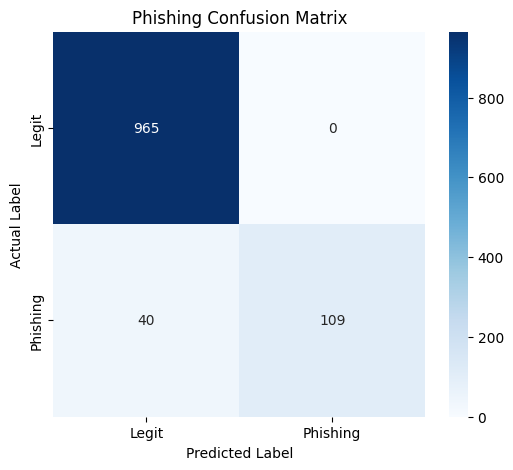

In [47]:
# Generate predictions first
y_pred = model.predict(X_test)

# Now create confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Phishing'],
            yticklabels=['Legit','Phishing'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Phishing Confusion Matrix")

plt.savefig("phishing_confusion_matrix.png")

plt.show()

# Actucal legit and predicted legit were correct.
# 40 were predicted as legit but they were phising.
# 109 were predicted as phising and were actully phising
# The model achieves high accuracy with zero false positives, though some phishing emails are missed.